# Full-data training frontier
**Alvaro Mendizabal · RSNA Knee Abnormality Detection · verified through Stages 33–36**

This executed publication notebook replays curated aggregate evidence only. It does **not** access AWS, poll Kaggle, expose study identifiers, or claim results from in-flight stages.

**Decision:** the data and grouped-validation contracts are complete; the remaining gap is model quality, cache-equivalence proof, fold-complete OOF training, and stronger structural representations.

In [1]:
import json, sys
from pathlib import Path
root=Path.cwd()
if not (root/'reports/training_frontier/results.json').is_file(): root=root.parent
D=json.loads((root/'reports/training_frontier/results.json').read_text())
sys.path.insert(0,str(root/'src'))
from rsna_research.training_frontier import coverage_fraction, leaderboard_gap, score_delta, candidate_state
print('Published evidence:',D['as_of_utc'])
print('Stage-36 submission:',D['leaderboard']['stage36_submission'],D['leaderboard']['stage36_public_auc'])
print('Cache coverage:',f"{100*coverage_fraction(D['training_data']['cached_studies'],D['training_data']['train_studies']):.1f}%")

Published evidence: 2026-09-24T02:47:36Z
Stage-36 submission: 56507693 0.82
Cache coverage: 100.0%


## 1. Official score boundary

Leaderboard AUC and local grouped AUC are kept separate. The independently trained DINO branch now has an official score, so its external position is no longer ambiguous.

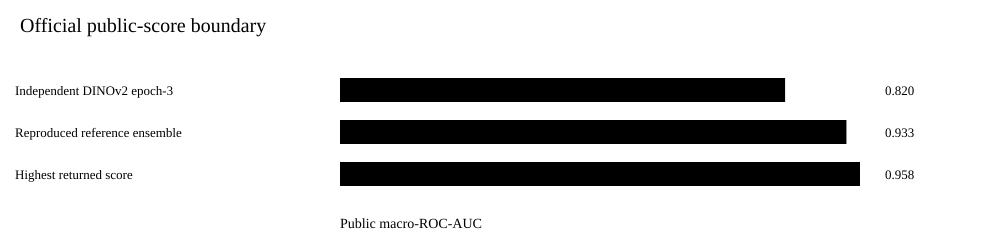

Comparable reference-to-leader gap: 0.025
Stage-36 state: AT_OR_BELOW_INCUMBENT


In [2]:
L=D['leaderboard']
gap=leaderboard_gap(L['reference_public_auc'],L['highest_returned_page_auc'])
print(f"Comparable reference-to-leader gap: {gap:.3f}")
print('Stage-36 state:',candidate_state(L['stage36_public_auc'],L['reference_public_auc']))

## 2. Complete data and scanner-grouped validation

Stage 33 closed the data-readiness gap: every training study is cached, all five validation folds are frozen by scanner group, and expert rows remain audit-only.

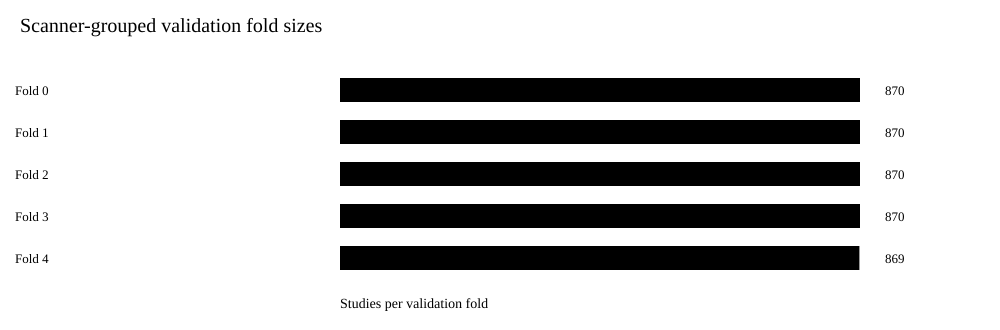

Cache: 4407 / 4407 studies | shards 14 / 14
Scanner groups: 59 | group leakage: False
Gold optimizer rows: 0 | audit-only rows: 58


In [3]:
T=D['training_data']; G=D['grouped_validation']
print('Cache:',T['cached_studies'],'/',T['train_studies'],'studies | shards',T['completed_shards'],'/',T['planned_shards'])
print('Scanner groups:',G['scanner_groups'],'| group leakage:',G['group_leakage'])
print('Gold optimizer rows:',G['gold_optimizer_rows'],'| audit-only rows:',G['gold_audit_rows'])

## 3. Stage-34 matched training result

The matched epoch-3 continuation improved the independent DINO branch. Agreement-weighted supervision did not beat that baseline and was stopped.

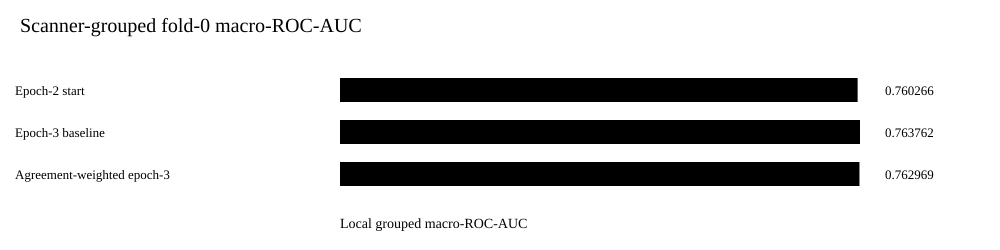

Baseline continuation gain: +0.003496
Consistency minus baseline: -0.000793
Decision: STOP_SUPERVISION_CONSISTENCY


In [4]:
S=D['stage34']
gain=score_delta(S['baseline_macro_auc'],S['starting_macro_auc'])
consistency_delta=score_delta(S['consistency_macro_auc'],S['baseline_macro_auc'])
print(f"Baseline continuation gain: {gain:+.6f}")
print(f"Consistency minus baseline: {consistency_delta:+.6f}")
print('Decision:',S['decision'])

## 4. Frontier backlog

The 0.820 official DINO score changes the optimization target. Minor continuation gains are useful diagnostics, but the main program must now produce stronger representations and fold-complete OOF evidence.

In [5]:
for row in D['research_backlog']:
    print(f"{row['rank']}. {row['capability']} — {row['status']} — priority {row['priority']}")
print('Next gate:',D['next_gate']['name'])
print('Status:',D['next_gate']['status'])

1. Cache-vs-direct model-logit equivalence — required before cache-backed five-fold training — priority 9.8
2. Trainable-depth capacity decision — last-4 versus last-6 DINO blocks; no public result claimed yet — priority 9.5
3. Scanner-grouped five-fold OOF baseline — data and folds ready; training not yet complete — priority 9.5
4. Geometry and slice-selection upgrade — next structural family if capacity change is insufficient — priority 9.0
5. Target-specific spatial / ROI modeling — not yet implemented for weak target families — priority 8.3
6. OOF heterogeneous ensemble — deferred until fold-complete predictions exist — priority 8.1
Next gate: Validate cache logits, resolve trainable depth, then train the full five-fold OOF system
Status: ACTIVE_RESEARCH_NOT_YET_PROMOTED


## 5. Research judgment

**What improved:** the project now has complete cache coverage, leakage-safe scanner-grouped folds, and a verified new-weight DINO continuation result.

**What failed:** agreement-weighted supervision underperformed its matched baseline, and the standalone epoch-3 DINO system scored only 0.820 publicly.

**What changes next:** require cache/direct equivalence, resolve trainable depth, move to fold-complete OOF training, then test structural geometry/ROI improvements and OOF-only heterogeneous ensembling.

Raw MRI, reports, study identifiers, scanner assignments, row-level predictions, weights, cache shards, private logs, environments, and credentials remain outside this public repository.

In [6]:
assert D['training_data']['cached_studies']==D['training_data']['train_studies']==4407
assert D['grouped_validation']['group_leakage'] is False
assert D['grouped_validation']['gold_optimizer_rows']==0
assert D['stage34']['consistency_macro_auc'] < D['stage34']['baseline_macro_auc']
assert D['leaderboard']['stage36_public_auc']==0.820
assert D['next_gate']['status']=='ACTIVE_RESEARCH_NOT_YET_PROMOTED'
print('RSNA_FULL_DATA_FRONTIER_PUBLICATION_COMPLETE')

RSNA_FULL_DATA_FRONTIER_PUBLICATION_COMPLETE
